# Step 1 

In [54]:
import os
import random
from pathlib import Path
from glob import glob

import pandas as pd
import numpy as np
from scipy.stats import entropy
from scipy.io import wavfile

import librosa
import librosa.display
import parselmouth
from parselmouth.praat import call
import noisereduce as nr
import pywt
import nolds
from pyrpde import rpde

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from tqdm import tqdm
from collections import Counter

import audioflux as af
from audioflux.type import SpectralFilterBankStyleType


In [3]:
def load_audio_files(directory):
    audio_files = []
    for filename in os.listdir(directory):
        if filename.endswith(".wav"):
            audio_files.append(os.path.join(directory, filename))
    return audio_files

In [4]:
def denoise(audio_files): # Takes a list of audio files
    path = Path(audio_files[0]).resolve()
    original_folder = path.parent
    
    new_folder_name = f"{original_folder.name}_noise_reduce"
    output_dir = original_folder.parent / new_folder_name
    output_dir.mkdir(parents=True, exist_ok=True)

    for audio_file in tqdm(audio_files, desc='Denoising Audio'):
        try:
            path = Path(audio_file).resolve()
            rate, data = wavfile.read(path)
            reduced_noise = nr.reduce_noise(y=data, sr=rate)
        
            file_name = path.name
            output_path = output_dir / f"reduced_{file_name}"    
            wavfile.write(output_path, rate, reduced_noise)
        except:
            print(f"Error processing {audio_file}")

    return output_dir

In [5]:
def extract_features(audio_file):
    sound = parselmouth.Sound(audio_file)
    pitch = sound.to_pitch()
    intensity = sound.to_intensity()

    pitch_mean = call(pitch, "Get mean", 0, 0, "Hertz")      # MDVP:Fo
    pitch_min = call(pitch, "Get minimum", 0, 0, "Hertz", "Parabolic") # MDVP:Flo
    pitch_max = call(pitch, "Get maximum", 0, 0, "Hertz", "Parabolic") # MDVP:Fhi
    longest_period = 1 / (pitch_min * 0.9)
    # intensity_mean = intensity.get_mean() 

    point_process = call(sound, "To PointProcess (periodic, cc)", pitch_min, pitch_max)
    
    local_jitter = call(point_process, "Get jitter (local)", 0, 0, 0.0001, longest_period, 1.3) # MDVP:Jitter(%)
    mdvp_jitter_percent = local_jitter
    mdvp_jitter_abs = call(point_process, "Get jitter (local, absolute)", 0, 0, 0.0001, longest_period, 1.3) # MDVP:Jitter(Abs)
    mdvp_rap = call(point_process, "Get jitter (rap)", 0, 0, 0.0001, longest_period, 1.3) # MDVP:RAP
    jitter_ppq = call(point_process, "Get jitter (ppq5)", 0, 0, 0.0001, longest_period, 1.3) # Jitter:ppq
    jitter_ddp = call(point_process, "Get jitter (ddp)", 0, 0, 0.0001, longest_period, 1.3) # Jitter:dpq

    mdvp_shimmer = call([sound, point_process], "Get shimmer (local)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # MDVP:Shimmer
    mdvp_shimmer_db = call([sound, point_process], "Get shimmer (local_dB)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # MDVP:Shimmer(dB)    
    shimmer_apq3 = call([sound, point_process], "Get shimmer (apq3)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # Shimmer:APQ3
    shimmer_apq5 = call([sound, point_process], "Get shimmer (apq5)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # Shimmer:APQ5
    shimmer_apq = call([sound, point_process], "Get shimmer (apq11)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # Shimmer:APQ
    shimmer_dda = call([sound, point_process], "Get shimmer (dda)", 0, 0, 0.0001, longest_period, 1.3, 1.6) # Shimmer:DDA


    harmonicity_obj = call(sound, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
    hnr = call(harmonicity_obj, "Get mean", 0, 0)

    data = sound.values.flatten()
    max_val = np.max(np.abs(data))
    if max_val > 0:
        data = (data / max_val) * 0.99 
    data = data.astype(np.float32)
    ent, histogram = rpde(data, tau=30, dim=3, epsilon=0.01, tmax=1500) 
    RPDE = ent.item() # RPDE
    
    pitch_values = pitch.selected_array['frequency']
    pitch_nonzero = pitch_values[pitch_values > 0]
    
    if len(pitch_nonzero) > 20:
        dfa_alpha = nolds.dfa(pitch_nonzero)
    else:
        dfa_alpha = np.nan

    # Extract pitch values (in Hz)
    pitch_values = pitch.selected_array['frequency']
    # Filter out unvoiced frames
    pitch_values = pitch_values[pitch_values > 0]
    
    # Convert to semitones (optional, but standard for PPE)
    semitones = 12 * np.log2(pitch_values / 110.0)
    
    # Calculate Probability Distribution
    value_counts, bin_edges = np.histogram(semitones, bins='auto', density=True)
    probabilities = value_counts / value_counts.sum()
    
    # Calculate Shannon Entropy
    ppe = entropy(probabilities)

    return {
        "MDVP:Jitter(%)": mdvp_jitter_percent,
        "MDVP:Jitter(Abs)": mdvp_jitter_abs,
        "MDVP:RAP": mdvp_rap,
        "Jitter:ppq": jitter_ppq,
        "Jitter:dpq": jitter_ddp,
        "MDVP:Shimmer": mdvp_shimmer,
        "MDVP:Shimmer(dB)": mdvp_shimmer_db,
        "Shimmer:APQ3": shimmer_apq3,
        "Shimmer:APQ5": shimmer_apq5,
        "MDVP:APQ": shimmer_apq,
        "Shimmer:DDA": shimmer_dda
        # "NHR": nhr,
        # "HNR": hnr,
        # "RPDE": RPDE,
        # "DFA": dfa_alpha,
        # "PPE": ppe
        # "D2": d2,
        
        # "pitch_mean": pitch_mean,
        # "pitch_min": pitch_min,
        # "pitch_max": pitch_max,
    }

# directory = "pd_dataset/HC_AH"
# audio_files = load_audio_files(directory)
# directory = denoise(audio_files) # Get directory of noise_reduced audio files


# audio_files = load_audio_files(directory)
# feature_list = []
# for audio_file in tqdm(audio_files[0:5]):
#     features = extract_features(audio_file)
#     feature_list.append(features)
    
# HC = pd.DataFrame(feature_list)
# HC['Target'] = 0
# display(HC)

| Feature          | Description                                                                                                    |   |   |
|------------------|----------------------------------------------------------------------------------------------------------------|---|---|
| MDVP:Jitter(%)   | [Kay Pentax MDVP jitter as a percentage](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| MDVP:Jitter(Abs) | [Kay Pentax MDVP absolute jitter in microseconds](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| MDVP:RAP         | [Kay Pentax MDVP Relative Amplitude Perturbation](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| MDVP:PPQ         | [Kay Pentax MDVP five-point Period Perturbation Quotient](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| Jitter:DDP       | [Average absolute difference of differences between cycles, divided by the average period](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                      |   |   |
| MDVP:Shimmer     | [Kay Pentax MDVP local shimmer](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| MDVP:Shimmer(dB) | [Kay Pentax MDVP local shimmer in decibels](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| Shimmer:APQ3     | [Three point Amplitude Perturbation Quotient](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| Shimmer:APQ5     | [Five point Amplitude Perturbation Quotient](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| MDVP:APQ         | [Kay Pentax MDVP 11-point Amplitude Perturbation Quotient](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| Shimmer:DDA      | [Average absolute difference between consecutive differences between the amplitudes of consecutive periods](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                      |   |   |
| NHR              | [Noise-to-Harmonics Ratio](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| HNR              | [Harmonics-to-Noise Ratio](https://www.researchgate.net/publication/208032992_PRAAT_a_system_for_doing_phonetics_by_computer)                                                           |   |   |
| RPDE             | [Recurrence Period Density Entropy](https://pmc.ncbi.nlm.nih.gov/articles/PMC1913514/)                     |   |   |
| DFA              | [Detrended Fluctuation Analysis](https://pmc.ncbi.nlm.nih.gov/articles/PMC1913514/)                        |   |   |
| D2               | Correlation dimension                                                                                      |   |   |
| PPE              | [Pitch period entropy](https://pmc.ncbi.nlm.nih.gov/articles/PMC3051371/#R23)                              |   |   |

In [7]:
directory = "pd_dataset/HC_AH"
audio_files = load_audio_files(directory)
directory = denoise(audio_files) # Get directory of noise_reduced audio files

audio_files = load_audio_files(directory)
feature_list = []
for audio_file in tqdm(audio_files):
    features = extract_features(audio_file)
    feature_list.append(features)
    
HC = pd.DataFrame(feature_list)
HC['target'] = 0
# display(HC)



directory = "pd_dataset/PD_AH"
audio_files = load_audio_files(directory)
directory = denoise(audio_files) # Get directory of noise_reduced audio files

audio_files = load_audio_files(directory)
feature_list = []
for audio_file in tqdm(audio_files):
    features = extract_features(audio_file)
    feature_list.append(features)
    
PD = pd.DataFrame(feature_list)
PD['target'] = 1
# display(PD)

df = pd.concat([PD, HC])
df

100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [01:24<00:00,  2.10s/it]


,MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,Jitter:ppq,Jitter:dpq,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,target
0,0.006772,0.000053,0.003795,0.003529,0.011385,0.088345,0.873681,0.043075,0.054943,0.093816,0.129224,1
1,0.005104,0.000046,0.002672,0.003241,0.008017,0.097266,0.897487,0.049546,0.064597,0.090725,0.148638,1
2,0.011475,0.000049,0.004808,0.004552,0.014424,0.092685,0.668337,0.041427,0.051467,0.042376,0.124281,1
3,0.009195,0.000035,0.004837,0.005839,0.014510,0.081788,0.648788,0.041762,0.054062,0.069867,0.125287,1
4,0.007648,0.000047,0.004507,0.005565,0.013522,0.068467,0.766103,0.021067,0.033468,0.068623,0.063201,1
...,...,...,...,...,...,...,...,...,...,...,...,...
36,0.004226,0.000023,0.002463,0.002584,0.007390,0.054683,0.508678,0.021491,0.030855,0.044046,0.064472,0
37,0.010660,0.000062,0.006445,0.006755,0.019336,0.091706,0.890142,0.043003,0.055139,0.081255,0.129009,0
38,0.009818,0.000118,0.004805,0.006409,0.014416,0.115180,1.053804,0.057834,0.078469,0.110357,0.173503,0
39,0.003978,0.000017,0.002280,0.002492,0.006841,0.052294,0.463785,0.024933,0.031400,0.040917,0.074798,0


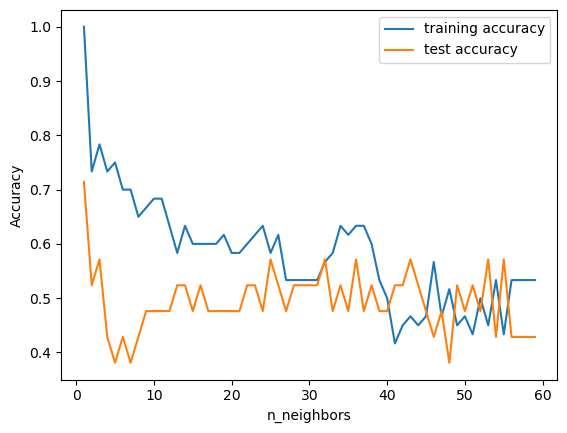

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(['target'], axis=1),df['target'],
                                                    test_size=0.25,random_state=42)

training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 60) # try n_neighbors from 1 to 50

for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)  # build the model
    clf.fit(X_train, y_train)

    training_accuracy.append(clf.score(X_train, y_train)) # record training set accuracy
    test_accuracy.append(clf.score(X_test, y_test))   # record generalization accuracy

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

pass

In [9]:
lahat_training = pd.DataFrame()
lahat_test = pd.DataFrame()
for seedN in tqdm(range(1, 50, 1), 'Testing Different Seeds'):
    X_train, X_test, y_train, y_test = train_test_split(df.drop(['target'], axis=1),df['target'],
                                                    test_size=0.25,random_state=seedN)

    training_accuracy = []
    test_accuracy = []
    neighbors_settings = range(1, 50) # try n_neighbors from 1 to 50

    for n_neighbors in neighbors_settings:
        clf = KNeighborsClassifier(n_neighbors=n_neighbors)  # build the model
        clf.fit(X_train, y_train)

        training_accuracy.append(clf.score(X_train, y_train)) # record training set accuracy
        test_accuracy.append(clf.score(X_test, y_test))   # record generalization accuracy

    lahat_training[seedN] = training_accuracy
    lahat_test[seedN] = test_accuracy

Testing Different Seeds: 100%|█████████████████████████████████████████████████████████| 49/49 [01:54<00:00,  2.33s/it]


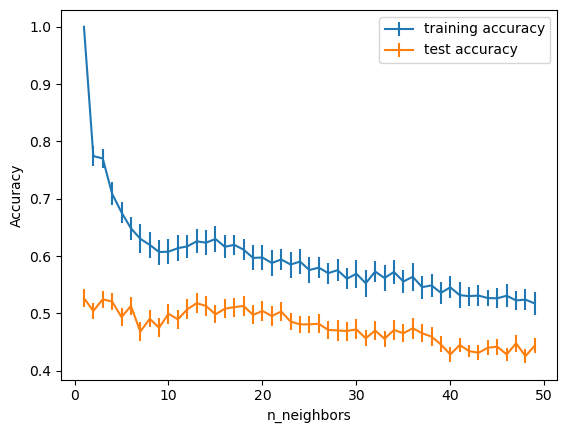

In [10]:
plt.errorbar(neighbors_settings, lahat_training.mean(axis=1),
             yerr=lahat_training.std(axis=1)/2, label="training accuracy")
plt.errorbar(neighbors_settings, lahat_test.mean(axis=1),
             yerr=lahat_test.std(axis=1)/6, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

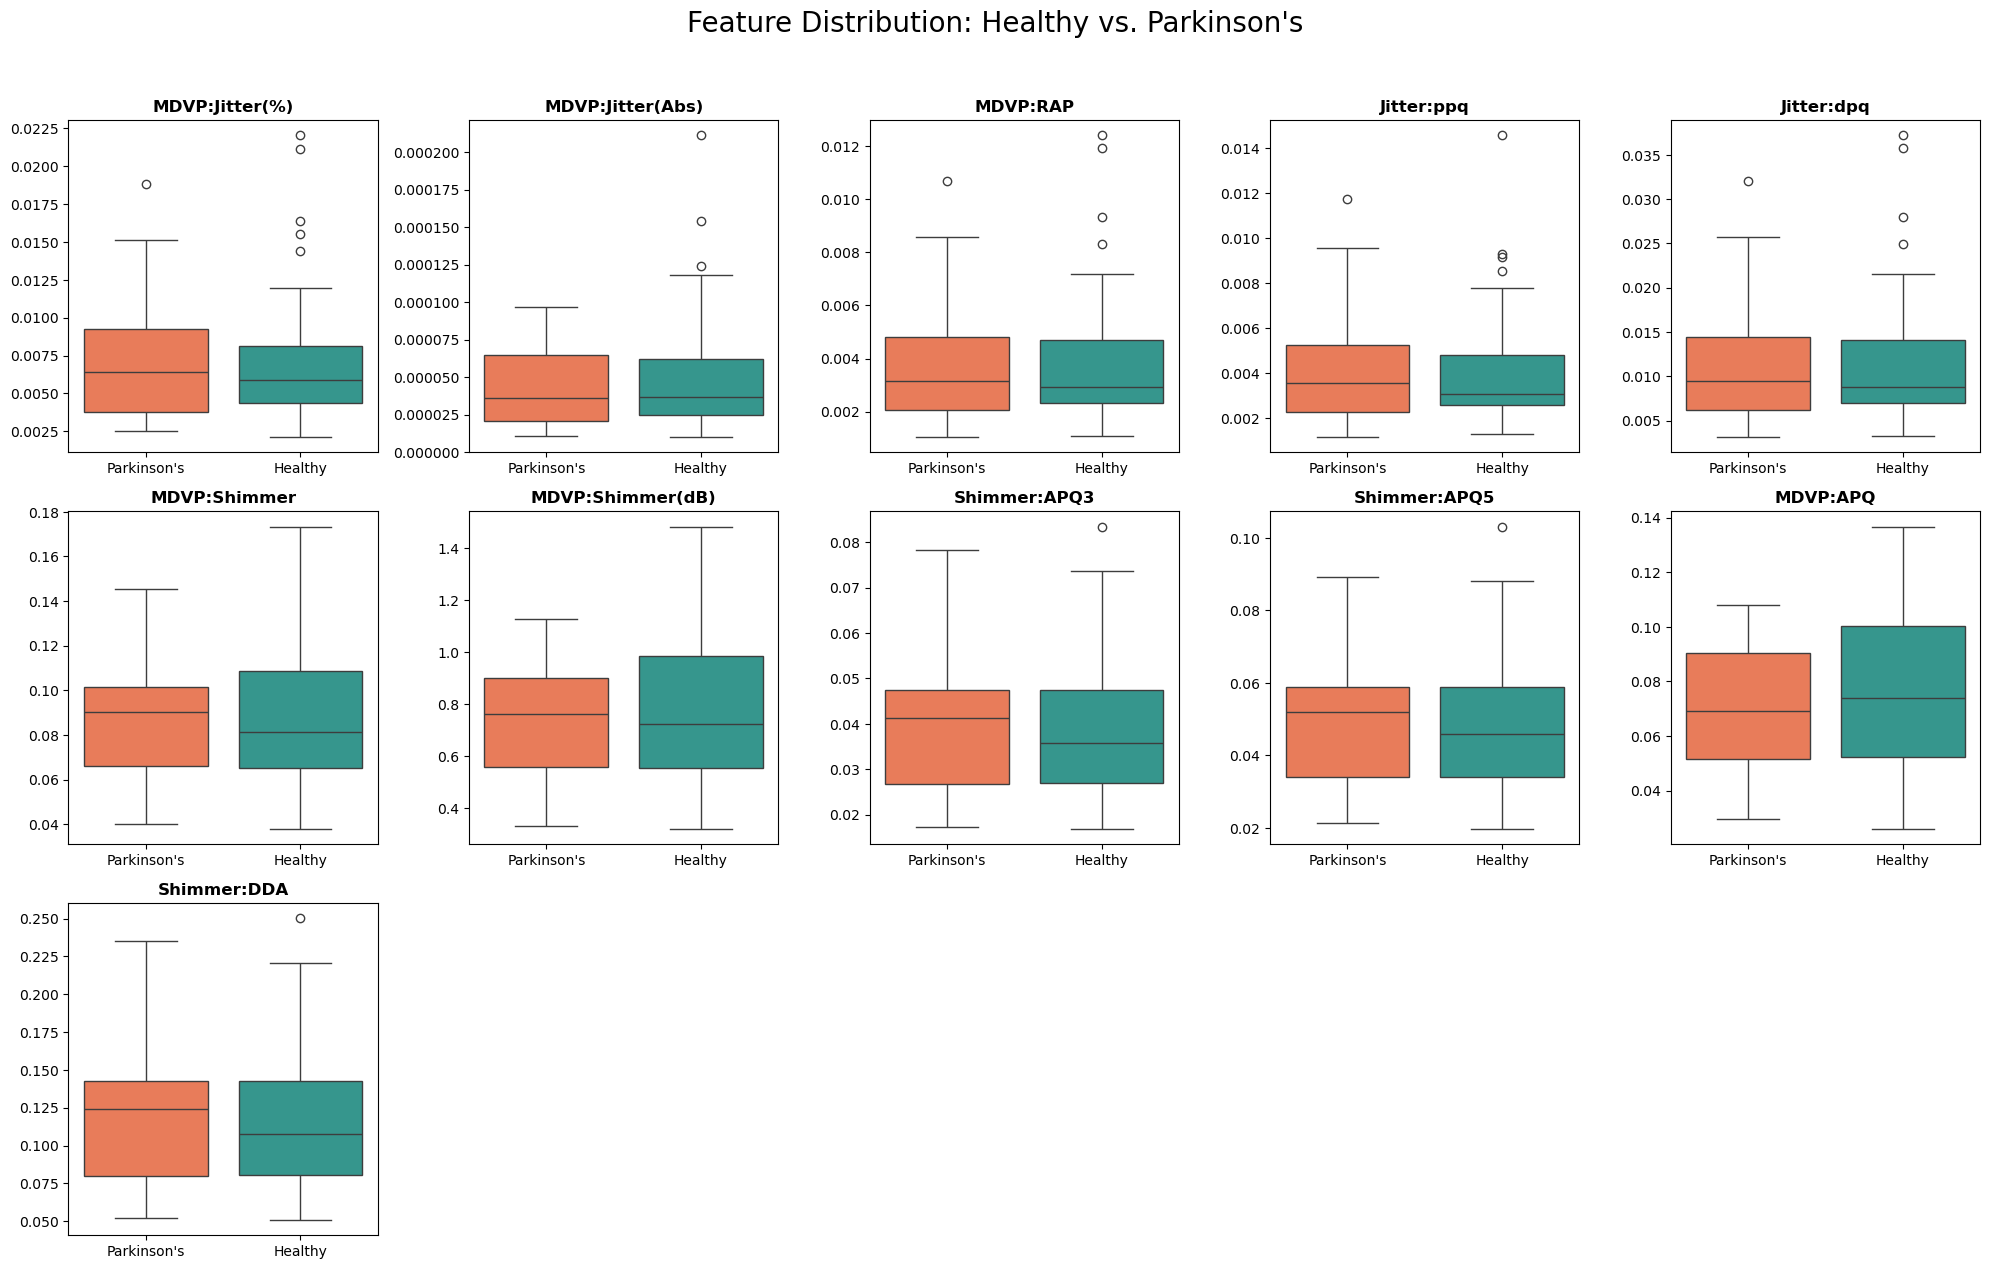

In [11]:
'''Code for EDA'''

# Convert labels for the legend/axis
df["target_label"] = df["target"].map({0: "Healthy", 1: "Parkinson's"})

# Get all features except the target 
feature_cols = [col for col in df.columns if col not in ['target', 'target_label']]

plt.figure(figsize=(20, 16))

# Define a color palette 
palette = { "Healthy": "#26a69a", "Parkinson's": "#ff7043" }

# Set up the graph format 
for i, feature in enumerate(feature_cols):
    plt.subplot(4, 5, i + 1)

    # plot 
    
    sns.boxplot(
        x="target_label", 
        y=feature, 
        data=df,
        palette=palette,
        hue="target_label", 
        legend=False
    )
    
    plt.title(feature, fontsize=12, fontweight='bold')
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Feature Distribution: Healthy vs. Parkinson's", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
'''Logistic regression with scaling for reproducibility''' 

X = df.select_dtypes(include=['number']).drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=30
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

# Predict
predictions = logreg_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.4


# Step 2

In [14]:
'''Code for Feature Extraction using STFT'''

# Setting targets for the audio files
data_map = {
    "pd_dataset/HC_AH_noise_reduce/*.wav": 0,    # Healthy Control
    "pd_dataset/PD_AH_noise_reduce/*.wav": 1     # Parkinson's Disease
}

features_list = []

for path_pattern, target in data_map.items():
    audio_files = glob(path_pattern)
    print(f"Processing {len(audio_files)} files for target: {target}")

    # Setting up a progress bar
    for file in tqdm(audio_files, desc=f"Target {target}", unit="file"):
        
        x, sr = librosa.load(file, sr=None)
        stft = np.abs(librosa.stft(x))

        # Feature Extraction
        mfcc1 = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc1, axis=1)

        spectral_centroid = librosa.feature.spectral_centroid(y=x, sr=sr)
        centroid_mean = np.mean(spectral_centroid)

        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=x, sr=sr)
        bandwidth_mean = np.mean(spectral_bandwidth)

        spectral_contrast = librosa.feature.spectral_contrast(S=stft, sr=sr, n_bands=3)
        contrast_mean = np.mean(spectral_contrast, axis=1)

        # Combine features + label
        feature_row = np.hstack([
            mfcc_mean,
            centroid_mean,
            bandwidth_mean,
            contrast_mean,
            target
        ])

        # Append everything 
        features_list.append(feature_row)

# Column Labels
mfcc_names = [f"mfcc_{i}" for i in range(1, 14)]
spectral_names = ["spectral_centroid", "spectral_bandwidth"]
contrast_names = [f"contrast_band_{i}" for i in range(1, 5)]
column_labels = mfcc_names + spectral_names + contrast_names + ["target"]

# Create DataFrame
df = pd.DataFrame(features_list, columns=column_labels)

print("Extraction Complete. Dataframe Shape:", df.shape)
df

Processing 41 files for target: 0


Target 0:   0%|                                                                               | 0/41 [00:00<?, ?file/s]C:\Users\jlgel\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
Target 0: 100%|██████████████████████████████████████████████████████████████████████| 41/41 [00:01<00:00, 22.78file/s]


Processing 40 files for target: 1


Target 1: 100%|██████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 81.10file/s]

Extraction Complete. Dataframe Shape: (81, 20)


,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_centroid,spectral_bandwidth,contrast_band_1,contrast_band_2,contrast_band_3,contrast_band_4,target
0,-34.671783,46.427185,-63.750423,-37.945095,-5.174286,-7.978308,-11.592722,7.337579,9.517365,-9.009621,-21.090189,-7.455282,-6.077338,1104.893589,741.075744,24.806168,27.109300,29.031058,29.002101,0.0
1,-51.353390,88.080132,-59.384941,-22.281412,-16.072655,-1.175686,-12.314146,-1.524578,0.616782,-12.499595,-9.319973,-13.819527,-2.889428,932.762445,658.452860,26.253622,25.037222,22.921611,27.640020,0.0
2,-75.293953,69.476532,-39.382324,-20.257771,-0.351907,0.462403,-16.158535,-2.635781,-15.651364,-16.545940,-8.706078,-8.037354,-8.123940,921.438546,725.465544,15.140855,30.398796,27.958255,29.106558,0.0
3,-32.810532,64.750412,-44.563965,-25.503115,-10.679801,0.391478,-19.562962,4.752218,0.198751,-25.886776,-19.472654,-13.636947,-1.386326,1023.948012,788.648102,27.203380,27.528240,27.385805,27.324650,0.0
4,-69.802628,41.698448,-55.650742,-45.029232,2.411105,8.187595,-28.289539,14.828458,-2.618405,-4.690909,-24.383987,-14.418140,7.071354,1229.625748,821.848030,22.416047,24.273961,26.204595,27.436695,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,-175.285690,38.995998,-36.874859,-34.680492,22.312656,-9.648567,-16.332352,5.128305,-9.038811,4.585876,-15.523121,3.245329,-15.609770,1349.832602,974.581309,23.384316,24.872782,25.014791,26.969288,1.0
77,-182.891846,55.136276,-31.717503,-49.519794,0.165608,11.415182,-20.467979,7.393897,1.737478,-1.373219,-22.136343,-15.020916,3.766758,1118.477422,826.369012,26.053243,25.043910,28.198584,28.063913,1.0
78,-64.881943,-20.999617,-51.011646,20.657621,-10.907411,-4.179439,15.597313,-22.053579,-18.473082,22.235464,-17.968420,-8.981183,-8.029469,1580.412201,718.134821,13.688773,28.211730,27.847201,30.238863,1.0
79,-80.320450,83.589615,-23.517599,-19.847649,-7.128909,-2.610546,-28.880053,-3.599473,10.541465,-11.141140,-20.561964,-25.042875,-2.383995,908.430621,783.307474,25.792100,25.800800,23.652257,25.577980,1.0


In [84]:
import audioflux as af
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import librosa

data_map = {
    "pd_dataset/HC_AH_noise_reduce/*.wav": 0,
    "pd_dataset/PD_AH_noise_reduce/*.wav": 1
}

features_list = []

for path_pattern, target in data_map.items():
    audio_files = glob(path_pattern)
    print(f"\nProcessing {len(audio_files)} files for target: {target}")

    for file in tqdm(audio_files, desc=f"Target {target}"):
        try:
            # 1. Load Audio - Force 16kHz to ensure Nyquist is at least 8kHz
            x, sr = librosa.load(file, sr=sr)
            
            # 2. MFCCs via AudioFlux
            mfccs, _ = af.mfcc(x, samplate=sr, cc_num=13)
            mfcc_mean = np.mean(mfccs, axis=1)

            # 3. Spectral Features via Librosa 
            centroid = np.mean(librosa.feature.spectral_centroid(y=x, sr=sr))
            bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=x, sr=sr))
            rolloff = np.mean(librosa.feature.spectral_rolloff(y=x, sr=sr))
            
            # 4. Spectral Contrast - REDUCED BANDS
            # We use n_bands=3 to ensure it fits within lower sample rate limits
            contrast = np.mean(librosa.feature.spectral_contrast(y=x, sr=sr, n_bands=3), axis=1)

            # 5. Combine everything
            feature_row = np.hstack([
                mfcc_mean, 
                centroid, 
                bandwidth, 
                rolloff, 
                contrast, 
                target
            ])
            features_list.append(feature_row)
            
        except Exception as e:
            print(f"Skipping {file}: {e}")
            continue

# --- Dynamic Column Naming based on contrast bands ---
num_contrast_channels = 3 + 1 # n_bands + 1
mfcc_cols = [f"mfcc_{i}" for i in range(1, 14)]
spectral_cols = ["centroid", "bandwidth", "rolloff"]
contrast_cols = [f"contrast_{i}" for i in range(1, num_contrast_channels + 1)]

df = pd.DataFrame(features_list, columns=mfcc_cols + spectral_cols + contrast_cols + ["target"])

print(f"\nSuccess! Total samples extracted: {len(df)}")
if not df.empty:
    print(df.head())


Processing 41 files for target: 0


Target 0: 100%|████████████████████████████████████████████████████████████████████████| 41/41 [00:01<00:00, 28.83it/s]



Processing 40 files for target: 1


Target 1: 100%|████████████████████████████████████████████████████████████████████████| 40/40 [00:01<00:00, 25.02it/s]



Success! Total samples extracted: 81
      mfcc_1    mfcc_2     mfcc_3    mfcc_4    mfcc_5    mfcc_6    mfcc_7  \
0 -25.207537 -1.339940 -11.087943 -3.756575  0.362238  0.269334 -1.259849   
1 -20.319965  7.525905  -8.359233 -2.098832 -2.542848  0.668663 -2.481976   
2 -24.379183  5.174233  -5.099149 -3.360593 -1.549207 -0.514683 -2.387515   
3 -19.572546  3.084876  -7.723890 -3.709388 -0.614625  0.305566 -3.211322   
4 -32.762119  1.271333  -8.893822 -4.114455  0.940653  0.479243 -3.541157   

     mfcc_8    mfcc_9   mfcc_10  ...   mfcc_12   mfcc_13     centroid  \
0  0.053825 -1.064828 -2.361245  ...  1.084839 -0.617027  1280.445120   
1 -1.263623 -0.966968 -2.493280  ... -0.595321 -0.634518   979.528564   
2 -1.353049 -1.615264 -1.378230  ... -0.070369  0.106610   962.934341   
3 -1.233668 -1.561505 -2.817199  ...  0.244079 -0.640979  1175.912207   
4  0.942396 -1.659372 -1.631622  ...  0.558106  1.053282  1375.297666   

    bandwidth      rolloff  contrast_1  contrast_2  contrast

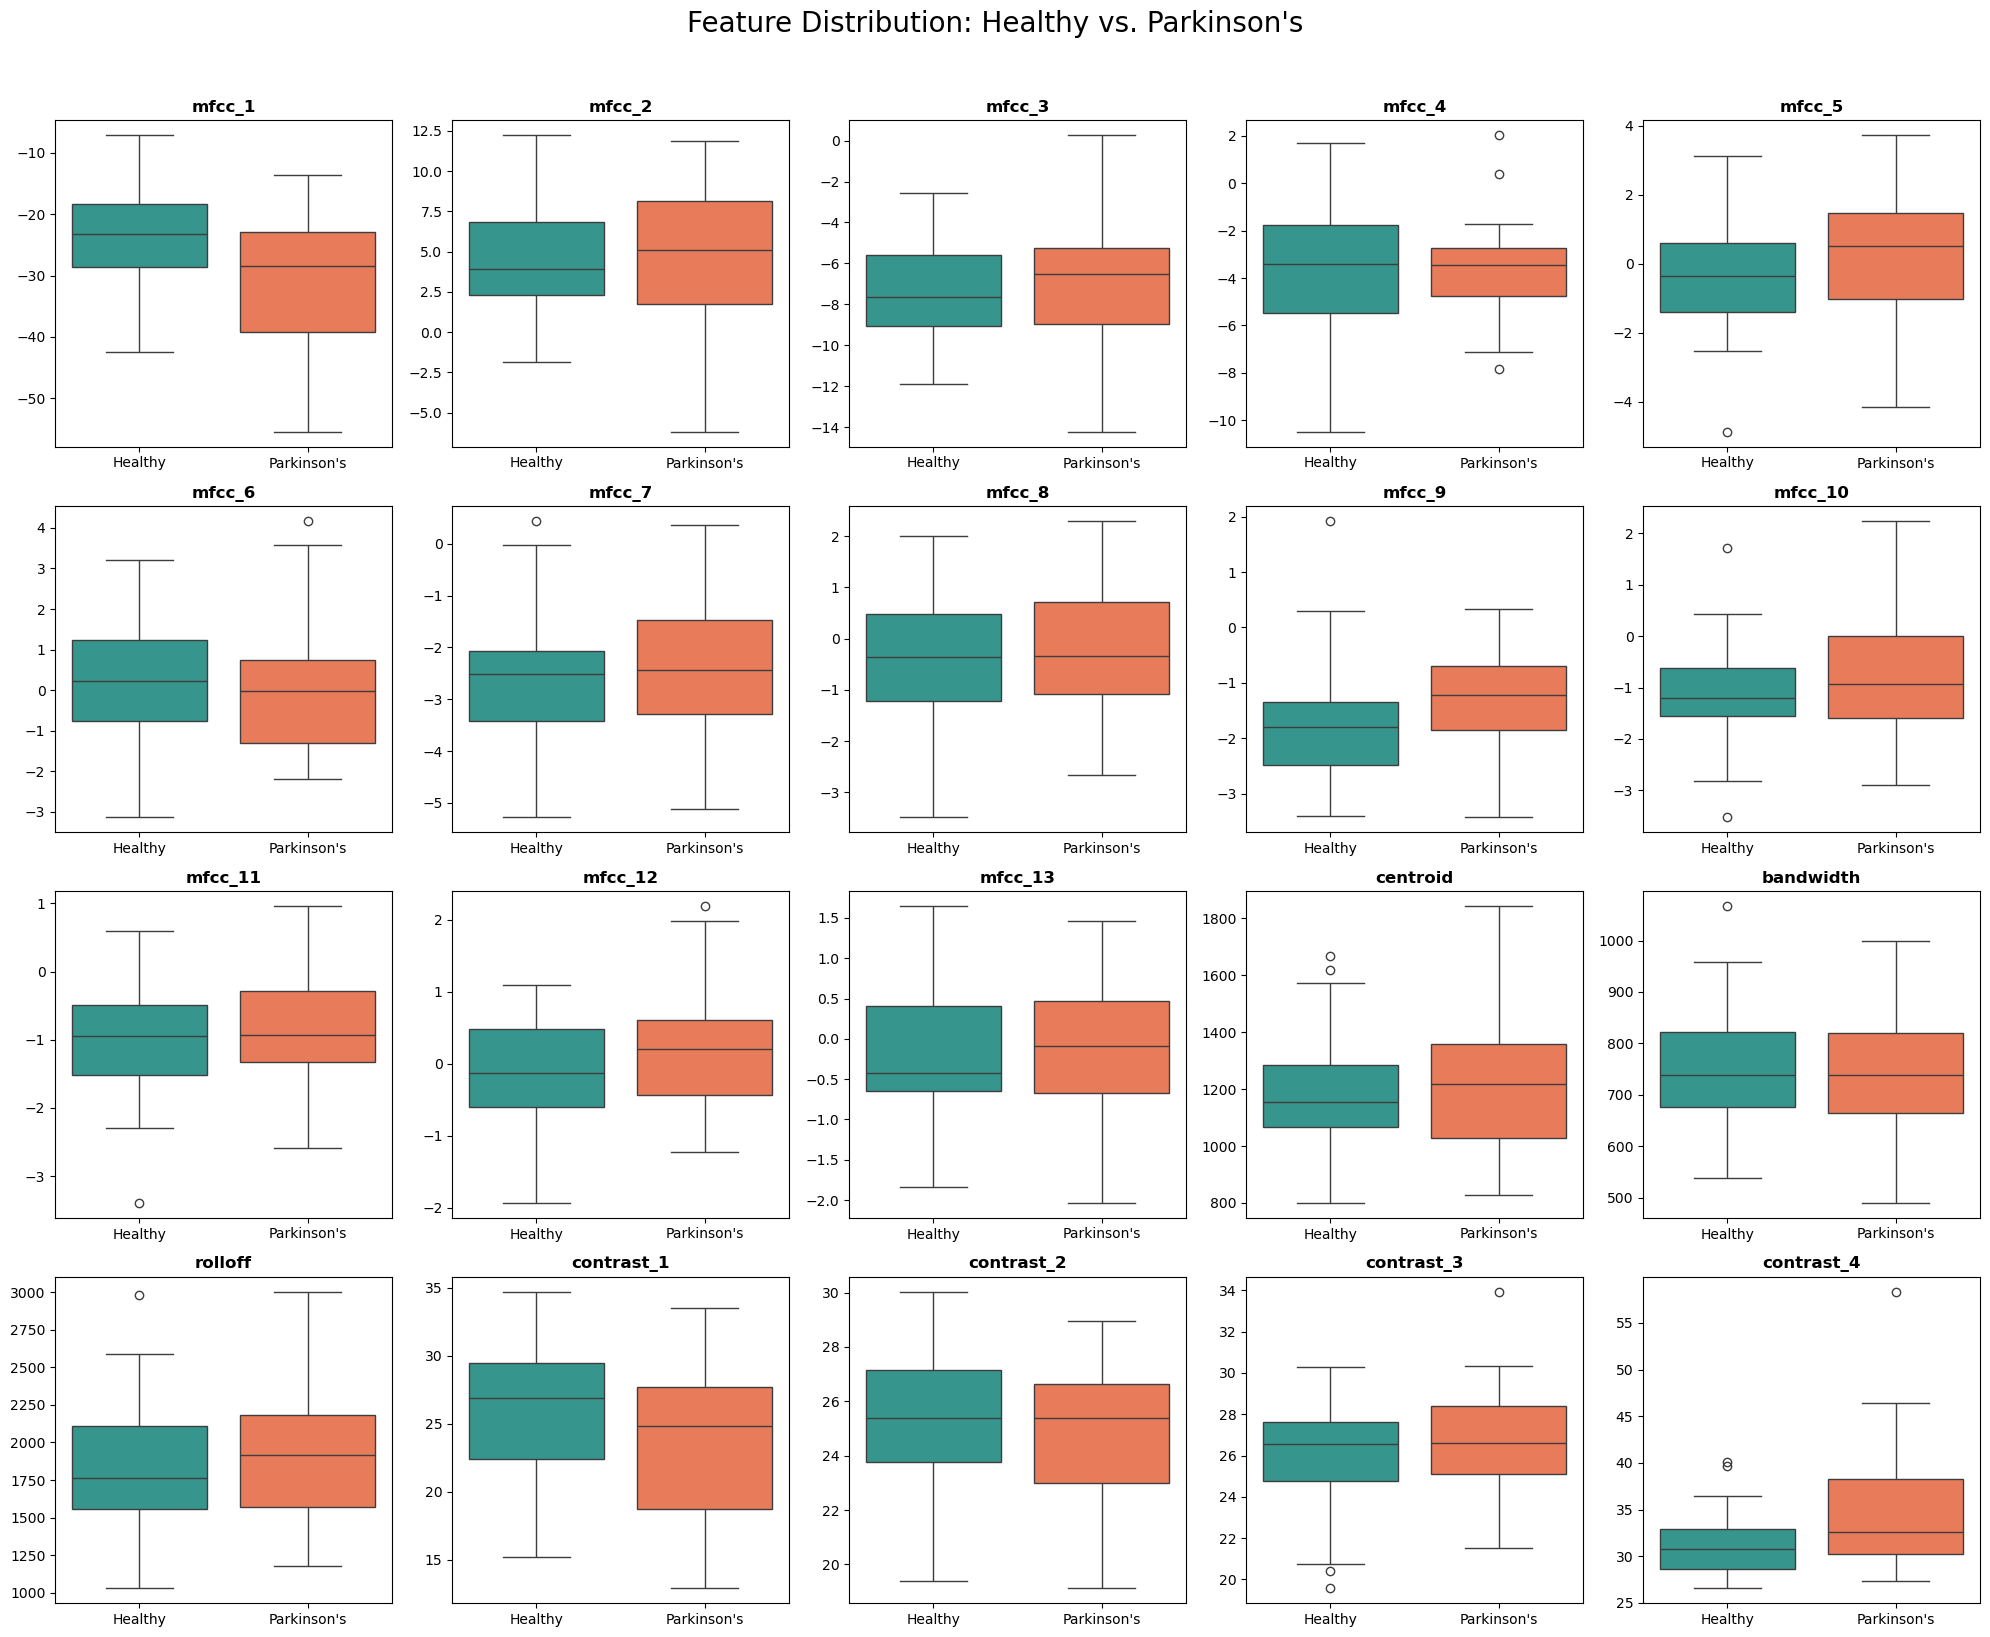

In [85]:
'''Code for EDA'''

# Convert labels for the legend/axis
df["target_label"] = df["target"].map({0: "Healthy", 1: "Parkinson's"})

# Get all features except the target 
feature_cols = [col for col in df.columns if col not in ['target', 'target_label']]

plt.figure(figsize=(20, 16))

# Define a color palette 
palette = { "Healthy": "#26a69a", "Parkinson's": "#ff7043" }

# Set up the graph format 
for i, feature in enumerate(feature_cols):
    plt.subplot(4, 5, i + 1)

    # plot 
    
    sns.boxplot(
        x="target_label", 
        y=feature, 
        data=df,
        palette=palette,
        hue="target_label", 
        legend=False
    )
    
    plt.title(feature, fontsize=12, fontweight='bold')
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Feature Distribution: Healthy vs. Parkinson's", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# Overview of Advanced Goal: Machine Learning 

For the advanced goal, this notebook intends to perform KNN, Random Forest, and logistic regression to classify the audio samples and evaluate which machine learning model most accurately distinguishes between healthy individuals and those with Parkinson's disease. 

The dataframe that combines all features from Step 1 and Step 2 will be fed into these models. Beyond simple classification, we analyze feature importance to pinpoint specific biomarkers that drive the model's decision. 

The performance of these models will further be measured not only by accuracy, but also through a detailed confusion matrix that will better ensure symptomatic individuals are correctly identified for further medical intervention. 

In [88]:
'''Logistic regression with scaling for reproducibility''' 

X = df.select_dtypes(include=['number']).drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=30
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

# Predict
predictions = logreg_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.8


In [112]:
'''KNN with random number of neighbors'''

# 1. Instantiate the class with a specific number of neighbors 19
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random.randint(1,100))
clf = KNeighborsClassifier(n_neighbors=14) 

# 2. Fit the model using the scaled training data
clf.fit(X_train, y_train) 

# 3. Evaluate the results
print("Train set accuracy: {:.2f}".format(clf.score(X_train, y_train)))
print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))

Train set accuracy: 0.57
Test set accuracy: 0.64


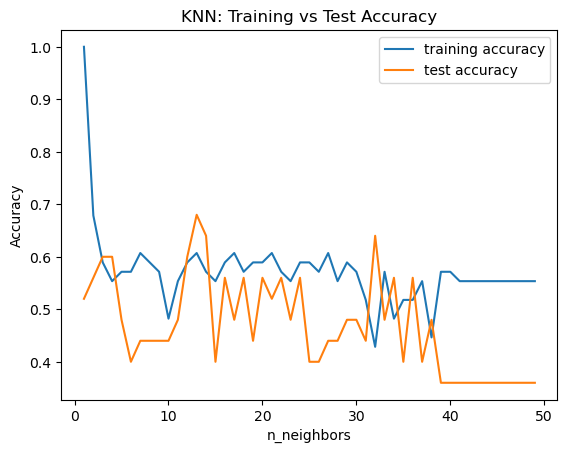

In [114]:
'''graphing the KNN: Training vs Test Accuracy (Monte Carlo Cross Validation)'''

training_accuracy = []
test_accuracy = []

# Try n_neighbors from 1 to 15 
neighbors_settings = range(1, 50)

for n_neighbors in neighbors_settings:
    # Build the model
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    
    # Record training set accuracy
    training_accuracy.append(clf.score(X_train, y_train))
    # Record generalization (test) accuracy
    test_accuracy.append(clf.score(X_test, y_test))

# Plotting
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.title("KNN: Training vs Test Accuracy")
plt.legend()
plt.show()

In [ ]:
'''Prof Gino's method (same thing but larger range)'''

lahat_training = pd.DataFrame()
lahat_test = pd.DataFrame()
for seedN in tqdm(range(1, 51, 1)):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, test_size=0.3, random_state=seedN
                                        )
    training_accuracy = []
    test_accuracy = []
    neighbors_settings = range(1, 50) # try n_neighbors from 1 to 50

    for n_neighbors in neighbors_settings:
        clf = KNeighborsClassifier(n_neighbors=n_neighbors)  # build the model
        clf.fit(X_train, y_train)

        training_accuracy.append(clf.score(X_train, y_train)) # record training set accuracy
        test_accuracy.append(clf.score(X_test, y_test))   # record generalization accuracy

    lahat_training[seedN]=training_accuracy
    lahat_test[seedN] = test_accuracy

  0%|                                                                                           | 0/50 [00:00<?, ?it/s]

In [102]:
print(f"Neighbors settings count: {len(neighbors_settings)}")
print(f"Training results count: {lahat_training.shape[0]}")
print(f"Test results count: {lahat_test.shape[0]}")

Neighbors settings count: 14
Training results count: 49
Test results count: 49


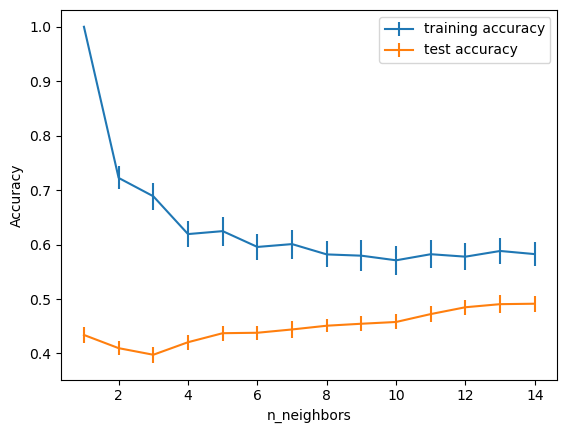

In [104]:
plt.errorbar(neighbors_settings, adjusted_training, 
             yerr=adjusted_err_train, label="training accuracy")
plt.errorbar(neighbors_settings, adjusted_test, 
             yerr=adjusted_err_test, label="test accuracy")

plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()
plt.show()

In [24]:
'''Random Forest Classifier''' 

# Making the Model 
rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees (default) 
    max_depth=None,         # max depth of each tree (None = expand until all leaves are pure)
    random_state=30,        # for reproducibility (followed the same num as in logistic regression)
    n_jobs=-1               # use all CPU cores
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6



Logistic Regression Confusion Matrix:
[[13  0]
 [12  0]]

KNN Confusion Matrix:
[[13  0]
 [12  0]]

Random Forest Confusion Matrix:
[[7 6]
 [4 8]]


C:\Users\jlgel\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


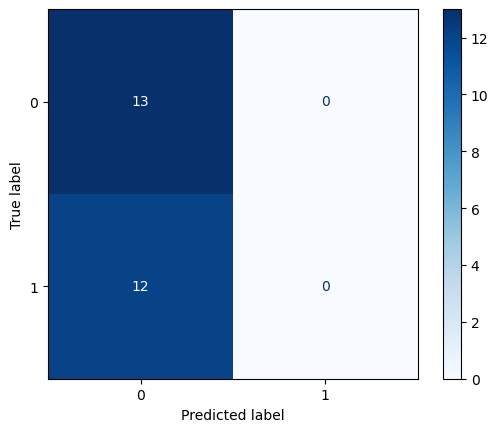

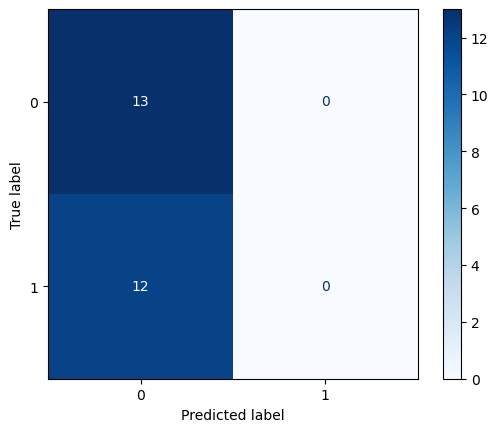

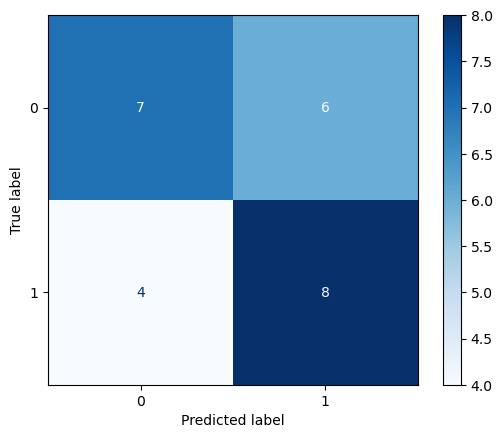

In [25]:
'''Confusion Matrix'''

models = {
    "Logistic Regression": logreg_model,
    "KNN": clf,
    "Random Forest": rf_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)  # predictions
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name} Confusion Matrix:")
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')  # nice blue color for visualization